In [8]:
# install
!pip install pmdarima kagglehub tqdm --quiet

In [9]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
from datetime import datetime
from tqdm.auto import tqdm
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings('ignore')

COINS = [
    'BTC-USD', 'ETH-USD', 'XRP-USD', 'BNB-USD', 'SOL-USD',
    'TRX-USD', 'DOGE-USD', 'ADA-USD', 'HYPE-USD', 'BCH-USD',
    'LINK-USD', 'LEO-USD', 'ZEC-USD', 'XLM-USD', 'XMR-USD',
    'LTC-USD', 'HBAR-USD', 'AVAX-USD'
]

TRAIN_DAYS = 730
TEST_DAYS = 365
HORIZONS = [1, 7]
REFIT_EVERY = 60

OUTPUT_DIR = '/content/arima_output/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Running ARIMA baseline for {len(COINS)} coins")


Running ARIMA baseline for 18 coins


In [10]:
# download data
import kagglehub
import glob

path = kagglehub.dataset_download("isaaclopgu/cryptocurrency-historical-prices-top-100-2025")
files = glob.glob(f"{path}/*.csv") + glob.glob(f"{path}/**/*.csv", recursive=True)
DATA_FILE = files[0]
print(f"Data: {DATA_FILE}")

# data cleaning
def load_data(filepath):
    df = pd.read_csv(filepath)
    df['Date'] = pd.to_datetime(df['Date'], utc=True).dt.tz_localize(None)
    df['Date'] = pd.to_datetime(df['Date'].dt.date)

    # only keep top 20 coins
    df = df[df['ticker'].isin(COINS)].copy()

    # clean up numeric columns
    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df = df.dropna(subset=['Open', 'High', 'Low', 'Close'])

    # fix any OHLC inconsistencies
    df['High'] = df[['Open', 'High', 'Low', 'Close']].max(axis=1)
    df['Low'] = df[['Open', 'High', 'Low', 'Close']].min(axis=1)

    # drop duplicates keep the one with higher volume
    df = df.sort_values(['ticker', 'Date', 'Volume'], ascending=[True, True, False])
    df = df.drop_duplicates(subset=['ticker', 'Date'], keep='first')

    # target variable
    df['PriceRange'] = df['High'] - df['Low']
    df['LogRange'] = np.log(df['PriceRange'].replace(0, np.nan))

    df = df.sort_values(['ticker', 'Date']).reset_index(drop=True)

    print(f"Loaded {len(df)} rows, {df['ticker'].nunique()} coins")
    return df

df = load_data(DATA_FILE)
df.to_csv(f"{OUTPUT_DIR}cleaned_data.csv", index=False)

Using Colab cache for faster access to the 'cryptocurrency-historical-prices-top-100-2025' dataset.
Data: /kaggle/input/cryptocurrency-historical-prices-top-100-2025/Crypto_historical_data.csv
Loaded 50540 rows, 18 coins


In [11]:
# ARIMA model

class ARIMABaseline:
    """ARIMA baseline with walk-forward validation"""

    def __init__(self, train_days, test_days, horizons, refit_every):
        self.train_days = train_days
        self.test_days = test_days
        self.horizons = horizons
        self.refit_every = refit_every

    def find_order(self, y):
        # BIC
        try:
            model = auto_arima(
                y, start_p=0, max_p=3, start_q=0, max_q=3,
                d=None, max_d=2, seasonal=False, stepwise=True,
                suppress_warnings=True, error_action='ignore',
                information_criterion='bic'
            )
            return model.order
        except:
            return (1, 1, 1)

    def run(self, df, ticker):
        coin = df[df['ticker'] == ticker].copy()
        coin = coin.sort_values('Date').reset_index(drop=True)

        n = len(coin)
        test_size = min(self.test_days, n - self.train_days)

        if test_size < 30:
            print(f"  {ticker}: not enough data (n={n})")
            return None

        test_start = n - test_size
        print(f"  {ticker}: n={n}, test from idx {test_start}")

        init_y = coin.iloc[:test_start]['LogRange'].dropna()
        order = self.find_order(init_y.tail(365))
        print(f"    order: {order}")

        results = {h: [] for h in self.horizons}
        refit_counter = 0
        expected_preds = {h: 0 for h in self.horizons}

        for i in tqdm(range(test_start, n), desc=f"    {ticker}", leave=False):
            refit_counter += 1

            # rolling window
            start = max(0, i - self.train_days)
            train = coin.iloc[start:i]
            y_train = train['LogRange'].dropna()

            if len(y_train) < 50:
                continue

            # refit
            if refit_counter >= self.refit_every:
                order = self.find_order(y_train.tail(365))
                refit_counter = 0

            # fit model
            try:
                model = ARIMA(y_train, order=order)
                fit = model.fit()
            except:
                continue

            # forecast horizon
            for h in self.horizons:
                target_idx = i + h - 1
                expected_preds[h] += 1

                if target_idx >= n:
                    continue

                actual = coin.iloc[target_idx]['LogRange']
                if pd.isna(actual):
                    continue

                try:
                    fc = fit.get_forecast(steps=h)
                    pred = fc.predicted_mean.iloc[-1]

                    # statsmodels CI
                    ci80 = fc.conf_int(alpha=0.20).iloc[-1]
                    ci95 = fc.conf_int(alpha=0.05).iloc[-1]

                    results[h].append({
                        'date': coin.iloc[target_idx]['Date'],
                        'actual': actual,
                        'predicted': pred,
                        'lower_80': ci80.iloc[0],
                        'upper_80': ci80.iloc[1],
                        'lower_95': ci95.iloc[0],
                        'upper_95': ci95.iloc[1]
                    })
                except:
                    continue

        # convert to dataframes
        for h in self.horizons:
            if results[h]:
                results[h] = pd.DataFrame(results[h])
            else:
                results[h] = pd.DataFrame()

        completion = {h: len(results[h]) / max(expected_preds[h], 1) for h in self.horizons}

        return {'ticker': ticker, 'order': order, 'results': results, 'completion': completion}

    def calc_metrics(self, res_df):
        if res_df.empty:
            return {}

        actual = res_df['actual'].values
        pred = res_df['predicted'].values

        mask = np.isfinite(actual) & np.isfinite(pred)
        actual, pred = actual[mask], pred[mask]

        if len(actual) == 0:
            return {}

        errors = actual - pred

        metrics = {
            'n': len(actual),
            'rmse': np.sqrt(np.mean(errors**2)),
            'mae': np.mean(np.abs(errors)),
            'bias': np.mean(errors)
        }

        # mape
        with np.errstate(divide='ignore', invalid='ignore'):
            ape = np.abs(errors / actual) * 100
            ape = ape[np.isfinite(ape)]
            metrics['mape'] = np.mean(ape) if len(ape) > 0 else np.nan

        # coverage
        l80, u80 = res_df['lower_80'].values[mask], res_df['upper_80'].values[mask]
        l95, u95 = res_df['lower_95'].values[mask], res_df['upper_95'].values[mask]

        metrics['coverage_80'] = np.mean((actual >= l80) & (actual <= u80)) * 100
        metrics['coverage_95'] = np.mean((actual >= l95) & (actual <= u95)) * 100
        metrics['width_80'] = np.mean(u80 - l80)
        metrics['width_95'] = np.mean(u95 - l95)

        return metrics

print("ARIMA class ready")

ARIMA class ready


In [12]:
# run ARIMA

model = ARIMABaseline(TRAIN_DAYS, TEST_DAYS, HORIZONS, REFIT_EVERY)
all_results = {}
all_metrics = []

for ticker in COINS:
    print(f"\n[{COINS.index(ticker)+1}/{len(COINS)}] {ticker}")

    try:
        result = model.run(df, ticker)
        if result is None:
            continue

        all_results[ticker] = result

        for h in HORIZONS:
            res_df = result['results'][h]
            if not res_df.empty:
                m = model.calc_metrics(res_df)
                m['ticker'] = ticker
                m['horizon'] = h
                m['order'] = str(result['order'])
                m['completion'] = result['completion'][h]
                all_metrics.append(m)

    except Exception as e:
        print(f"  error: {e}")

metrics_df = pd.DataFrame(all_metrics)
metrics_df.to_csv(f"{OUTPUT_DIR}arima_metrics.csv", index=False)

print("ARIMA Baseline results")
print(metrics_df.round(3).to_string(index=False))


[1/18] BTC-USD
  BTC-USD: n=4095, test from idx 3730
    order: (0, 1, 2)


    BTC-USD:   0%|          | 0/365 [00:00<?, ?it/s]


[2/18] ETH-USD
  ETH-USD: n=2946, test from idx 2581
    order: (1, 0, 2)


    ETH-USD:   0%|          | 0/365 [00:00<?, ?it/s]


[3/18] XRP-USD
  XRP-USD: n=2946, test from idx 2581
    order: (1, 0, 2)


...


[17/18] HBAR-USD
  HBAR-USD: n=2269, test from idx 1904
    order: (1, 1, 1)


    HBAR-USD:   0%|          | 0/365 [00:00<?, ?it/s]


[18/18] AVAX-USD
  AVAX-USD: n=1900, test from idx 1535
    order: (0, 1, 1)


    AVAX-USD:   0%|          | 0/365 [00:00<?, ?it/s]

ARIMA Baseline results
  n  rmse   mae   bias    mape  coverage_80  coverage_95  width_80  width_95   ticker  horizon     order  completion
365 0.544 0.428 -0.005   5.462       81.096       95.068     1.447     2.213  BTC-USD        1 (0, 1, 2)       1.000
359 0.571 0.450 -0.006   5.739       83.844       96.936     1.565     2.393  BTC-USD        7 (0, 1, 2)       0.984
365 0.536 0.422  0.021   8.682       81.918       94.795     1.326     2.028  ETH-USD        1 (1, 1, 1)       1.000
359 0.591 0.471  0.051   9.672       80.223       93.872     1.450     2.217  ETH-USD        7 (1, 1, 1)       0.984
365 0.540 0.416  0.011  29.780       84.384       95.616     1.445     2.210  XRP-USD        1 (1, 1, 1)       1.000
359 0.631 0.484  0.040  35.736       85.237       96.379     1.776     2.716  XRP-USD        7 (1, 1, 1)       0.984
365 0.512 0.406  0.013  13.554       82.466       96.438     1.336     2.043  BNB-USD        1 (1, 1, 1)       1.000
359 0.606 0.482  0.047  15.985       80.7


Plots saved to /content/arima_output/


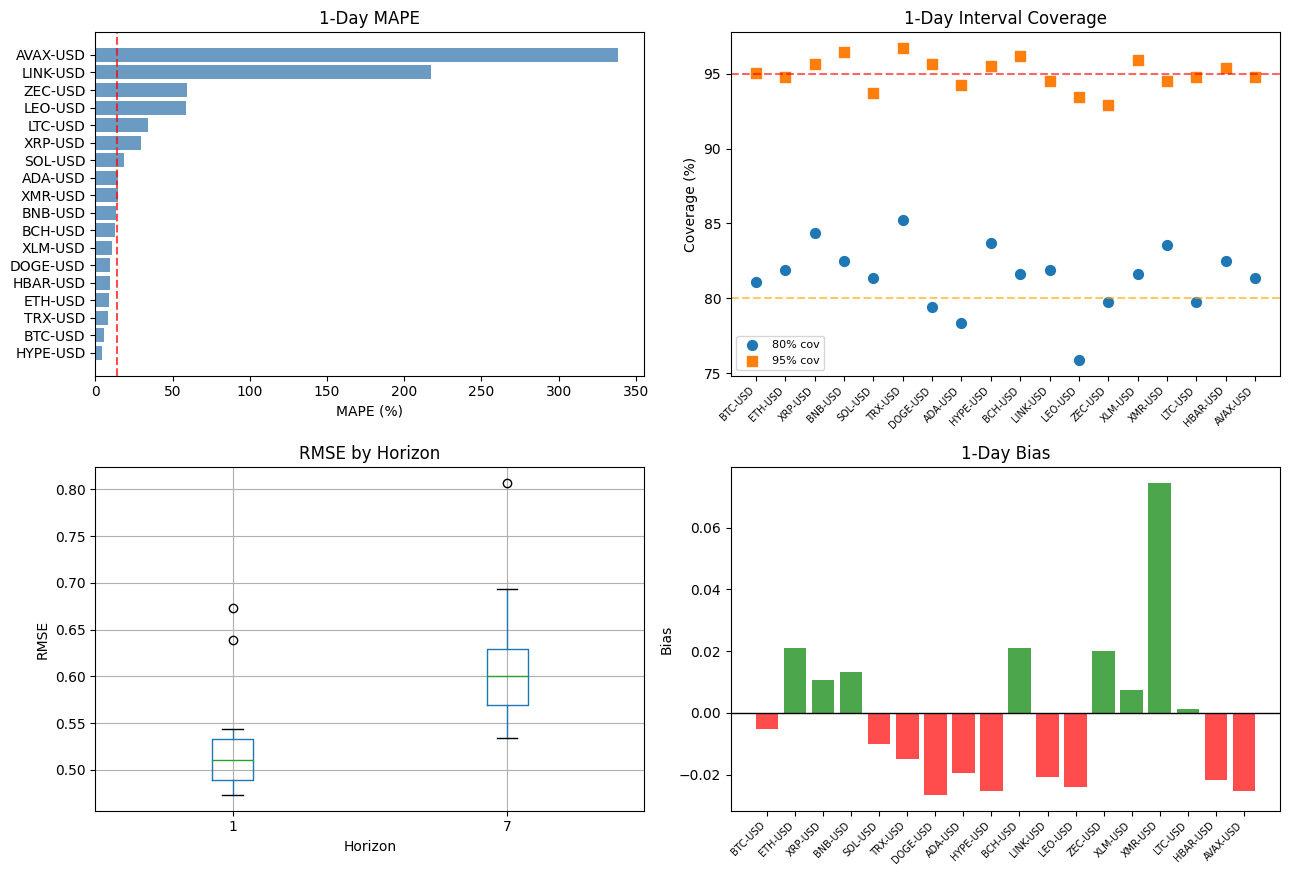

In [13]:
# plots

def plot_results(result, ticker, output_dir):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for idx, h in enumerate(HORIZONS):
        res = result['results'][h]
        if res.empty:
            continue

        ax = axes[idx, 0]

        # forecast plot
        ax.fill_between(res['date'], res['lower_95'], res['upper_95'],
                       alpha=0.15, color='blue', label='95% CI')
        ax.fill_between(res['date'], res['lower_80'], res['upper_80'],
                       alpha=0.25, color='blue', label='80% CI')
        ax.plot(res['date'], res['actual'], 'k.-', ms=2, alpha=0.6, label='Actual')
        ax.plot(res['date'], res['predicted'], 'r-', lw=1, alpha=0.8, label='Forecast')

        ax.set_title(f'{ticker} - {h}-Day Forecast')
        ax.set_ylabel('Log(Price Range)')
        ax.legend(loc='upper right', fontsize=8)
        ax.tick_params(axis='x', rotation=30)

        ymin, ymax = ax.get_ylim()
        padding = (ymax - ymin) * 0.1
        ax.set_ylim(ymin - padding, ymax + padding)

        # error histogram
        ax2 = axes[idx, 1]
        errors = res['actual'] - res['predicted']
        ax2.hist(errors, bins=25, alpha=0.7, edgecolor='black', density=True)
        ax2.axvline(0, color='red', linestyle='--')
        ax2.axvline(errors.mean(), color='green', label=f'mean={errors.mean():.3f}')
        ax2.set_title(f'{ticker} - {h}-Day Errors')
        ax2.set_xlabel('Error')
        ax2.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(f"{output_dir}{ticker.replace('-', '_')}_arima.png", dpi=120, bbox_inches='tight')
    plt.close()

for ticker, result in all_results.items():
    plot_results(result, ticker, OUTPUT_DIR)

print(f"\nPlots saved to {OUTPUT_DIR}")

#summary plot
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# mape by coin
ax1 = axes[0, 0]
h1 = metrics_df[metrics_df['horizon'] == 1].sort_values('mape')
ax1.barh(h1['ticker'], h1['mape'], color='steelblue', alpha=0.8)
ax1.set_xlabel('MAPE (%)')
ax1.set_title('1-Day MAPE')
ax1.axvline(h1['mape'].median(), color='red', linestyle='--', alpha=0.7)

# coverage
ax2 = axes[0, 1]
h1 = metrics_df[metrics_df['horizon'] == 1]
ax2.scatter(range(len(h1)), h1['coverage_80'], label='80% cov', s=50)
ax2.scatter(range(len(h1)), h1['coverage_95'], label='95% cov', s=50, marker='s')
ax2.axhline(80, color='orange', linestyle='--', alpha=0.6)
ax2.axhline(95, color='red', linestyle='--', alpha=0.6)
ax2.set_xticks(range(len(h1)))
ax2.set_xticklabels(h1['ticker'], rotation=45, ha='right', fontsize=7)
ax2.set_ylabel('Coverage (%)')
ax2.set_title('1-Day Interval Coverage')
ax2.legend(fontsize=8)

# rmse by horizon
ax3 = axes[1, 0]
metrics_df.boxplot(column='rmse', by='horizon', ax=ax3)
ax3.set_title('RMSE by Horizon')
ax3.set_xlabel('Horizon')
ax3.set_ylabel('RMSE')
plt.suptitle('')

# bias
ax4 = axes[1, 1]
h1 = metrics_df[metrics_df['horizon'] == 1]
colors = ['green' if b > 0 else 'red' for b in h1['bias']]
ax4.bar(range(len(h1)), h1['bias'], color=colors, alpha=0.7)
ax4.set_xticks(range(len(h1)))
ax4.set_xticklabels(h1['ticker'], rotation=45, ha='right', fontsize=7)
ax4.axhline(0, color='black', lw=1)
ax4.set_ylabel('Bias')
ax4.set_title('1-Day Bias')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}arima_summary.png", dpi=120, bbox_inches='tight')
plt.show()


In [14]:
# final summary
print("SUMMARY")

for h in HORIZONS:
    hdata = metrics_df[metrics_df['horizon'] == h]
    print(f"\n{h}-Day Horizon:")
    print(f"  Coins: {len(hdata)}")
    print(f"  Total predictions: {hdata['n'].sum()}")
    print(f"  Mean MAPE: {hdata['mape'].mean():.1f}%")
    print(f"  Mean RMSE: {hdata['rmse'].mean():.3f}")
    print(f"  80% Coverage: {hdata['coverage_80'].mean():.1f}% (target: 80%)")
    print(f"  95% Coverage: {hdata['coverage_95'].mean():.1f}% (target: 95%)")
    print(f"  Mean completion: {hdata['completion'].mean():.1%}")

# download
from google.colab import files
import shutil

shutil.make_archive('/content/arima_results', 'zip', OUTPUT_DIR)
files.download('/content/arima_results.zip')

SUMMARY

1-Day Horizon:
  Coins: 18
  Total predictions: 6561
  Mean MAPE: 48.2%
  Mean RMSE: 0.524
  80% Coverage: 81.4% (target: 80%)
  95% Coverage: 95.0% (target: 95%)
  Mean completion: 99.9%

7-Day Horizon:
  Coins: 18
  Total predictions: 6453
  Mean MAPE: 51.2%
  Mean RMSE: 0.609
  80% Coverage: 83.0% (target: 80%)
  95% Coverage: 95.9% (target: 95%)
  Mean completion: 98.2%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>